<center></a>
<center><font size=8>AI-Driven Stock News Sentiment Analysis</center></font>
<center><img src="https://media2.dev.to/dynamic/image/width=1000,height=500,fit=cover,gravity=auto,format=auto/https%3A%2F%2Fdev-to-uploads.s3.amazonaws.com%2Fuploads%2Farticles%2Fazlkmjqtpzy6l4tade7o.png" width="720"/></center>

## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Installing and Importing the necessary libraries**

In [78]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2

In [79]:
# to read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

## **Loading the dataset**

In [80]:
# Mount Google Drive to the /content/drive directory to access the files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [81]:
# loading data into a pandas dataframe
News = pd.read_csv("/content/drive/MyDrive/Dataset/GenAIDataset/stock_news.csv")

In [82]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [83]:
# creating a copy of the data
data = News.copy()

## **Data Overview**

###**Checking the first 5 rows**

In [84]:
data.head()

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,"Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets",41.740002,42.244999,41.482498,40.246914,130672400,-1


###**Checking the last 5 rows**

In [85]:
data.tail()

,Date,News,Open,High,Low,Close,Volume,Label
344,2019-04-30,"Media mogul Oprah Winfrey, known for influencing millions with her opinions on diets and books, is considering which Democratic presidential candidate to endorse in 2020. She told the Hollywood Reporter she's ""quietly figuring out where I'm going to use my voice"" and will make a clear announcement",50.764999,50.849998,49.7775,48.70879,186139600,-1
345,2019-04-30,"European shares fell on Tuesday, with banks underperforming amid a decline in China's manufacturing activity and awaiting euro zone economic growth numbers. The pan-European STOXX 600 index dropped 0.7% while major indices fell except London's FTSE 100. Danske Bank plunged",50.764999,50.849998,49.7775,48.70879,186139600,-1
346,2019-04-30,"This article reports that the S&P 500 reached another record high close on Tuesday, marking its best four-month stretch since late 2010. Apple's strong quarterly results and positive earnings forecast helped ease concerns about the bull run's sustainability, despite a revenue miss from Google parent Alphabet. The",50.764999,50.849998,49.7775,48.70879,186139600,-1
347,2019-04-30,"The Federal Reserve is anticipated to keep interest rates unchanged in their upcoming meeting, with a likelihood of a rate cut expected later this year. The Fed Chairman's press conference may provide significant market impact as investors seek insights on economic growth and inflation. Apple's earnings report exceeded expectations, leading to a post-market surge in shares, while",50.764999,50.849998,49.7775,48.70879,186139600,-1
348,2019-04-30,"In the first quarter, South Korea's Samsung Electronics reported its weakest profit in over two years due to falls in chip prices and slowing demand for display panels. The tech giant expects improved results in the second half of 2019, driven by a pickup in memory chip and smartphone sales. However, memory chip",50.764999,50.849998,49.7775,48.70879,186139600,0


###**Checking the shape of the data**

In [86]:
data.shape

(349, 8)

* The dataset has 349 rows and 8 columns.

###**Checking for missing values**

In [87]:
data.isnull().sum()

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


* There are no missing values.

### **Checking for duplicate values**

In [88]:
data.duplicated().sum()

0

* There are no duplicate values in the dataset.

## **Exploratory Data Analysis**

In [89]:
# To display the structure of data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


* To get the information about the dataset.

In [90]:
#converting object column 'Date' to datetime
data['Date'] = pd.to_datetime(data['Date'])

In [91]:
# To ensure the data type of Date
print(data['Date'].dtype)

datetime64[ns]


In [92]:
# summary statistics for each numeric column
summary = data.describe()
print(summary)


                                Date        Open        High         Low  \
count                            349  349.000000  349.000000  349.000000   
mean   2019-02-16 16:05:30.085959936   46.229233   46.700458   45.745394   
min              2019-01-02 00:00:00   37.567501   37.817501   37.305000   
25%              2019-01-14 00:00:00   41.740002   42.244999   41.482498   
50%              2019-02-05 00:00:00   45.974998   46.025002   45.639999   
75%              2019-03-22 00:00:00   50.707500   50.849998   49.777500   
max              2019-04-30 00:00:00   66.817497   67.062500   65.862503   
std                              NaN    6.442817    6.507321    6.391976   

            Close        Volume       Label  
count  349.000000  3.490000e+02  349.000000  
mean    44.926317  1.289482e+08   -0.054441  
min     36.254131  4.544800e+07   -1.000000  
25%     40.246914  1.032720e+08   -1.000000  
50%     44.596924  1.156272e+08    0.000000  
75%     49.110790  1.511252e+08    0.00

### **Univariate Analysis**

* Distribution of individual variables
* Compute and check the distribution of the length of news content
* Monthwise Analysis

### **Distribution of Sentiment polarity and all Numeric Variables**

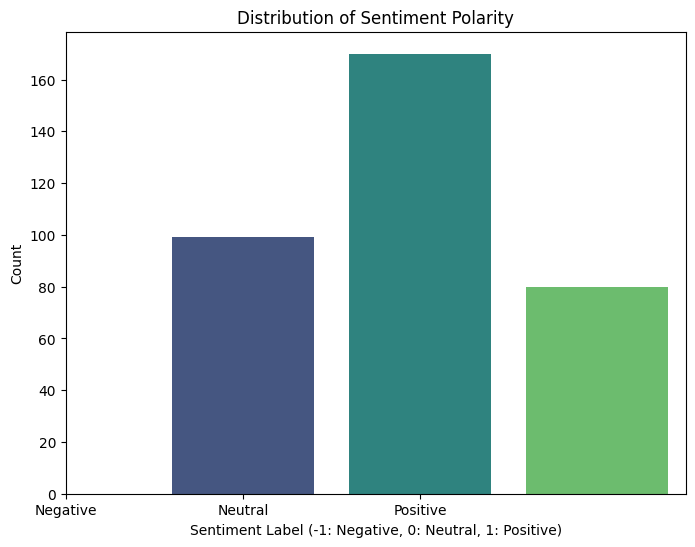

In [93]:
# Plot the distribution of sentiment polarity
plt.figure(figsize=(8, 6))
sns.countplot(x='Label', data=data, palette='viridis')
plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Sentiment Label (-1: Negative, 0: Neutral, 1: Positive)')
plt.ylabel('Count')
plt.xticks(ticks=[-1, 0, 1], labels=['Negative', 'Neutral', 'Positive'])
plt.show()

* Shows the number of Positive, Neutral and Negative news.

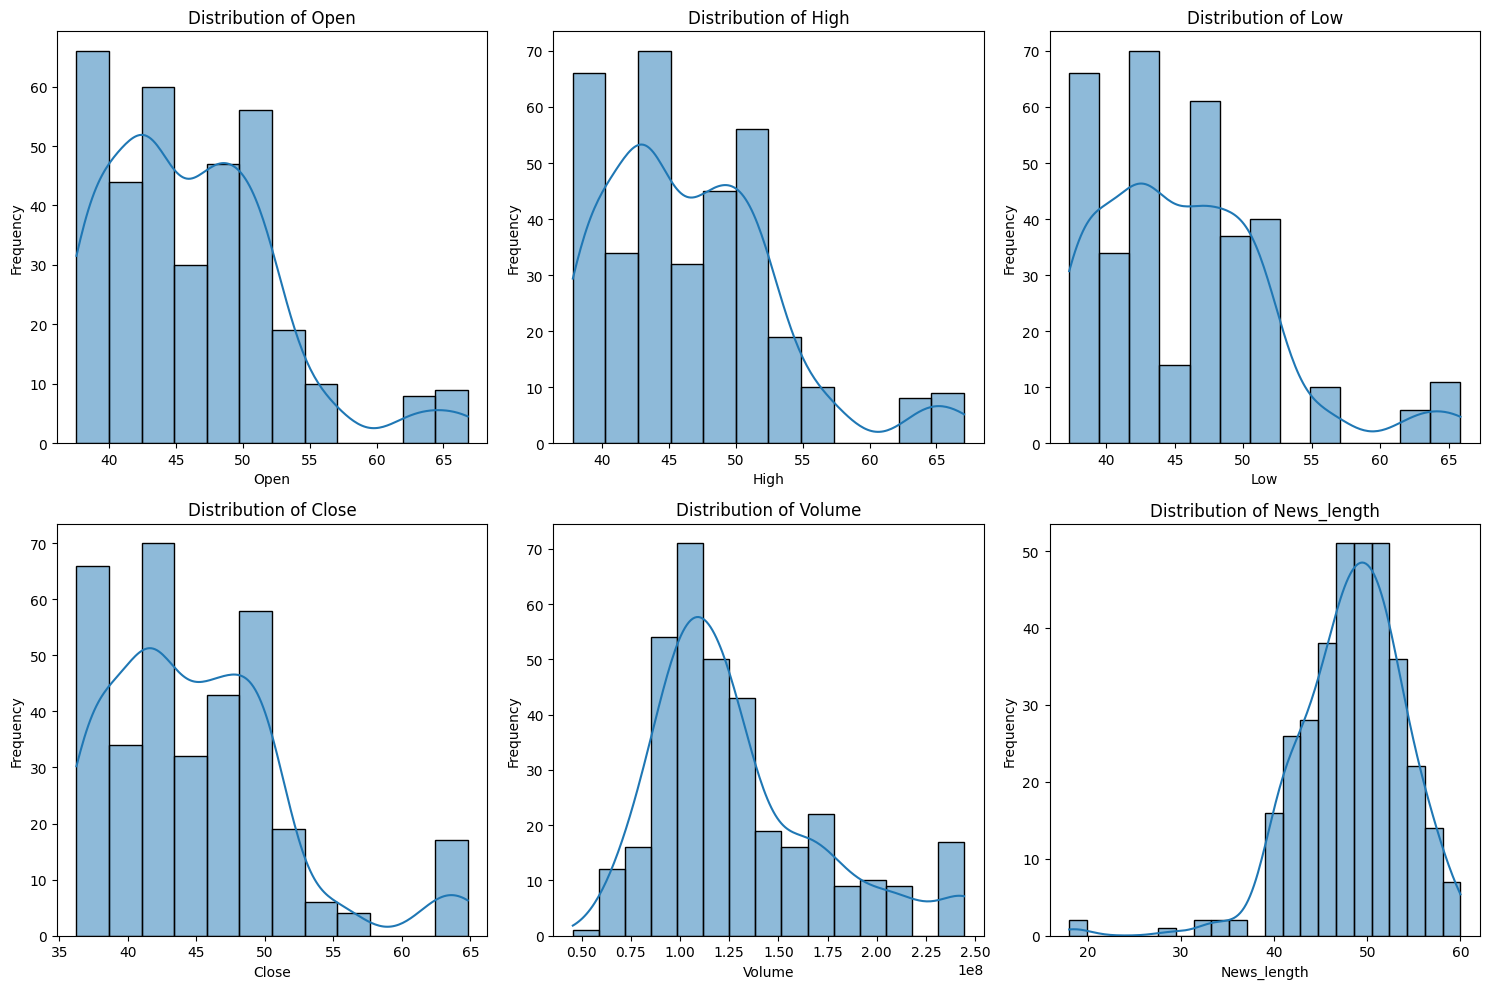

In [94]:
# Plot Distribution of all Numeric variables
# Compute length of news content (in words)
data['News_length'] = data['News'].apply(lambda x: len(x.split()))
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'News_length']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

* Displays the distribution of stock prices and volume.

### **Distribution of the length of news content**

In [95]:
# Compute length of news content (in words)
data['News_length'] = data['News'].apply(lambda x: len(x.split()))

# Summary statistics of news length
summary = data['News_length'].describe()
print(summary)



count    349.000000
mean      48.349570
std        5.717324
min       18.000000
25%       45.000000
50%       49.000000
75%       52.000000
max       60.000000
Name: News_length, dtype: float64


* Calculates the number of words in each news article.
* Gives min, max, mean, quartiles etc.

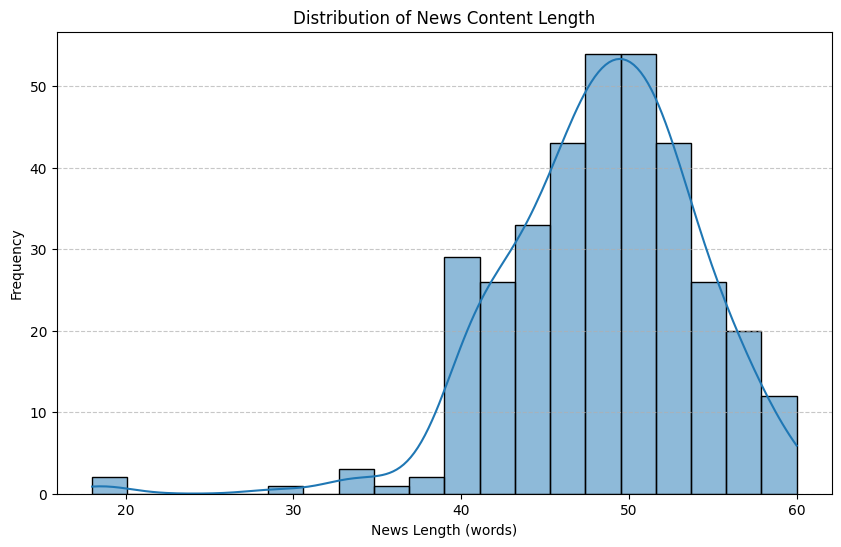

In [96]:
# Plot distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['News_length'], kde=True, bins=20)
plt.title('Distribution of News Content Length')
plt.xlabel('News Length (words)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

* Shows how article lengths are distributed.

### **Monthwise Analysis**

In [97]:
#Create a YearMonth column
data['YearMonth'] = data['Date'].dt.to_period('M').astype(str)

# Group by YearMonth and calculate averages
monthwise_avg = (
    data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']]
      .mean()
      .reset_index()
)

print(monthwise_avg)

  YearMonth       High        Low       Open      Close        Volume
0   2019-01  44.024216  43.023629  43.550407  42.252099  1.393266e+08
1   2019-02  48.140754  47.365095  47.674387  46.376751  1.013622e+08
2   2019-03  48.007575  46.920933  47.566045  46.139134  1.413169e+08
3   2019-04  51.150357  50.304246  50.650277  49.462640  1.116555e+08


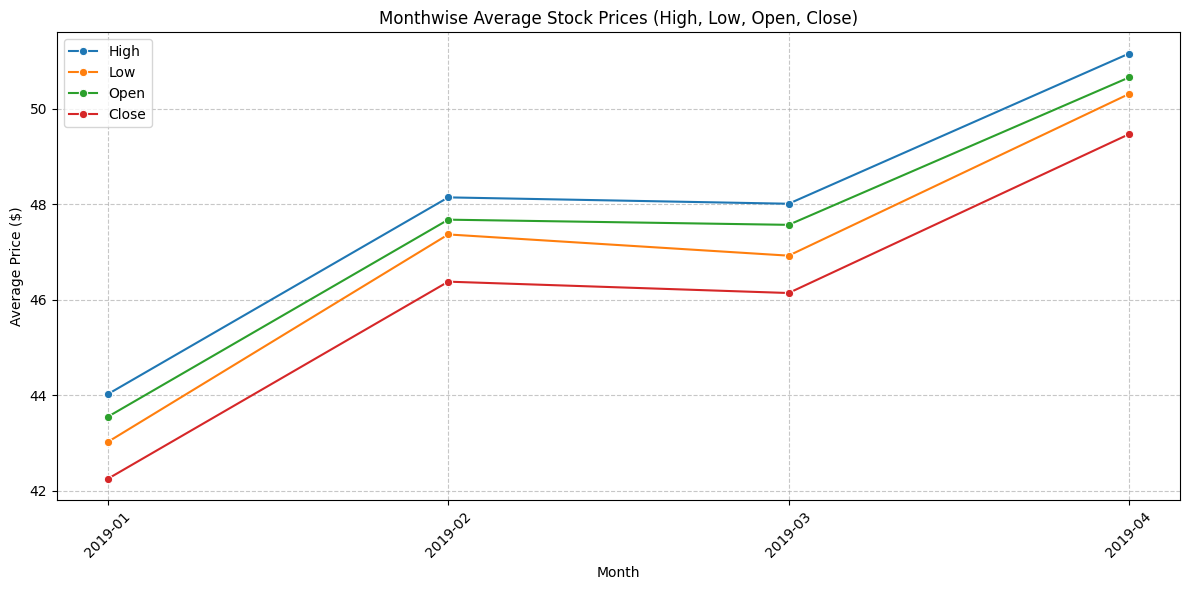

In [98]:
# plot the monthwise averages of all price variables for better visualization
plt.figure(figsize=(12, 6))
for col in ['High', 'Low', 'Open', 'Close']:
    sns.lineplot(x='YearMonth', y=col, data=monthwise_avg, marker='o', label=col)

plt.title('Monthwise Average Stock Prices (High, Low, Open, Close)')
plt.xlabel('Month')
plt.ylabel('Average Price ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

* Price Trend (High, Low, Open, Close) shows that there is a steady increase in all price measures from January to April 2019.

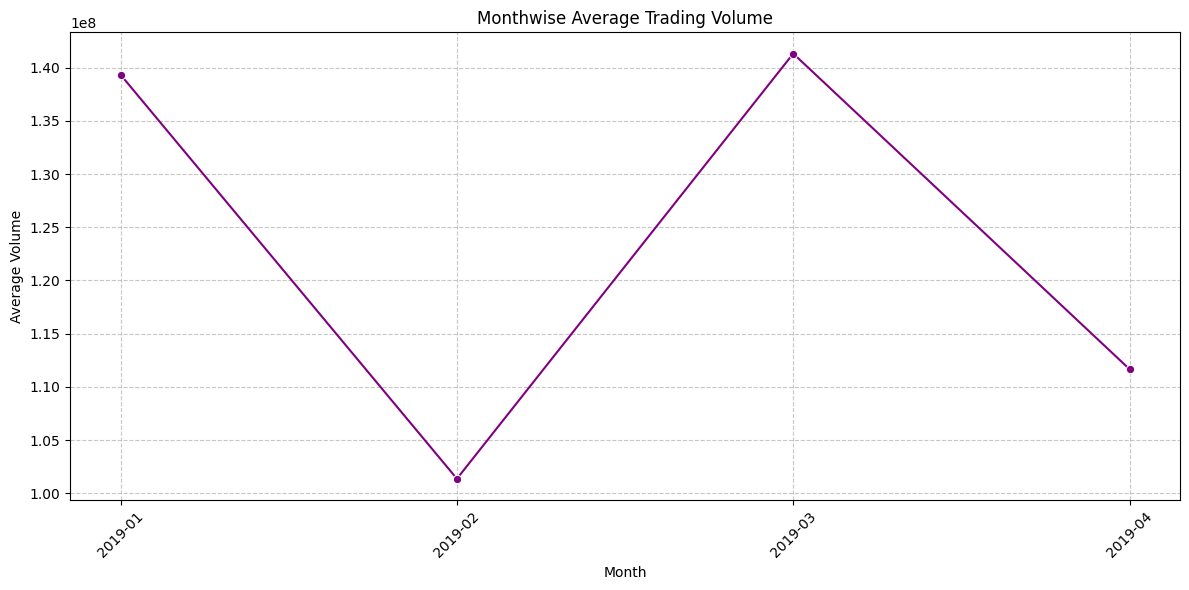

In [99]:
#plot the trend of monthwise averages in Volume
plt.figure(figsize=(12, 6))
sns.lineplot(x='YearMonth', y='Volume', data=monthwise_avg, marker='o', color='purple')
plt.title('Monthwise Average Trading Volume')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* Displays monthly average trending volume

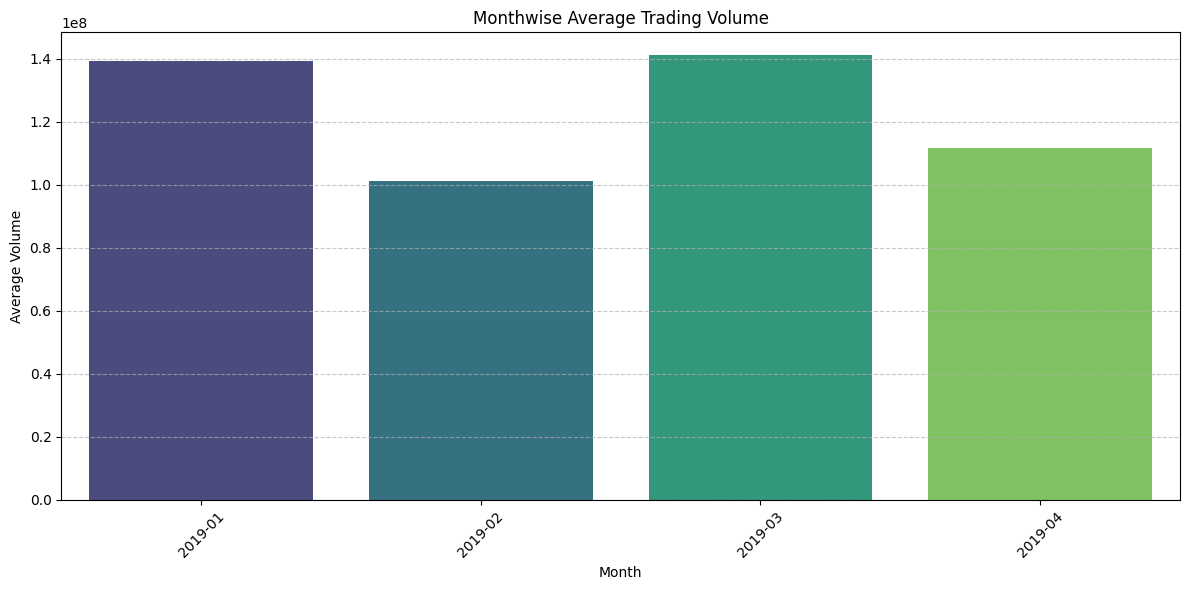

In [100]:
# Bar plot of the monthwise averages in Volume
plt.figure(figsize=(12, 6))
sns.barplot(x='YearMonth', y='Volume', data=monthwise_avg, palette='viridis')
plt.title('Monthwise Average Trading Volume')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* Compares monthly average trending volume.

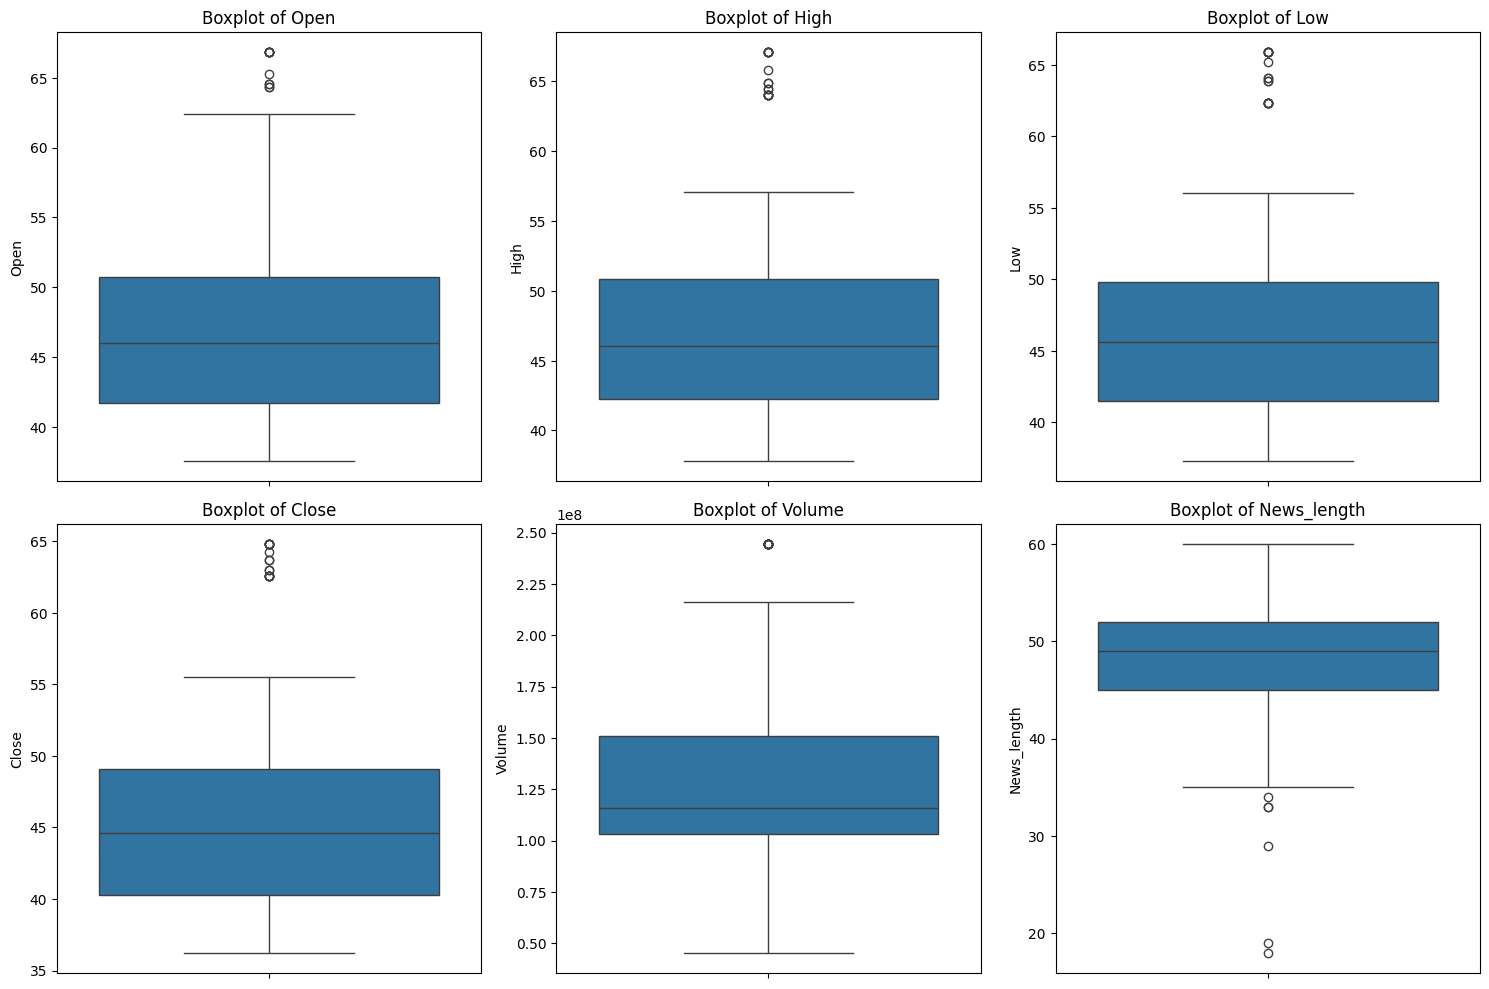

In [101]:
# Boxplot to identify outliers
numeric_cols_for_boxplot = ['Open', 'High', 'Low', 'Close', 'Volume', 'News_length']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols_for_boxplot):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

* Detects outliers in stock price variables.

### **Bivariate Analysis**

* Correlation
* Sentiment Polarity vs Price
* Date vs Price
* Distribution of News Length Across Sentiment Categories



### **Correlation**

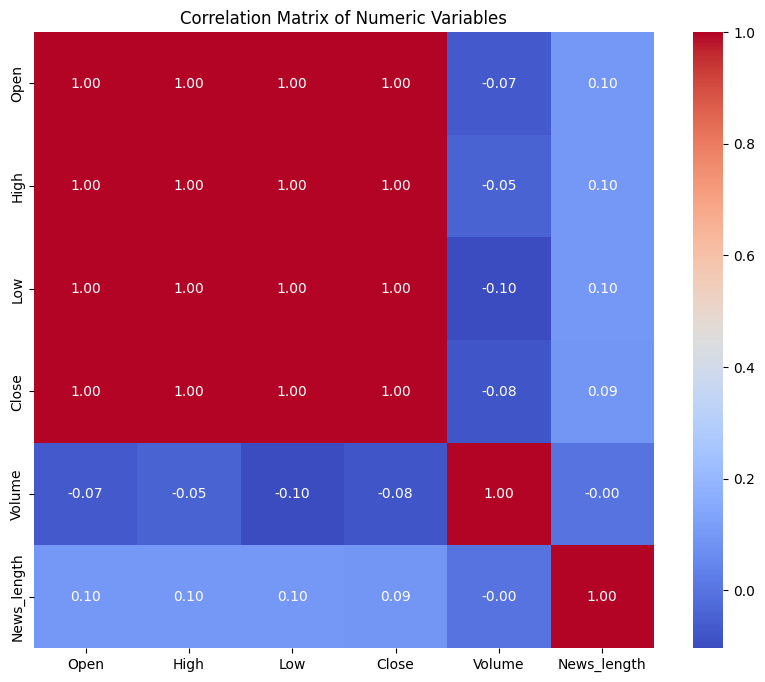

In [102]:
# Correlation matrix to check if variables move together or have correlations
correlation_matrix = data[numeric_cols_for_boxplot].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Variables')
plt.show()

* Shows correlation among numeric variables.

### **Sentiment Polarity vs Price**

In [103]:
#Sentiment Polarity with all numeric variables
price_volume_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
sentiment_price_corr = data[price_volume_cols].corrwith(data['Label'])

print('Correlation between Sentiment Polarity and Price/Volume Variables:')
print(sentiment_price_corr)

Correlation between Sentiment Polarity and Price/Volume Variables:
Open      0.066042
High      0.065504
Low       0.062131
Close     0.060144
Volume   -0.012572
dtype: float64


* This code measures how strongly each stock price and trading volume feature is related to the sentiment polarity (Label). Correlation values range from -1 to +1, where:

+1 → Strong positive relationship

-1 → Strong negative relationship

0 → No relationship

### **Time Series Analysis (Date vs Price)**

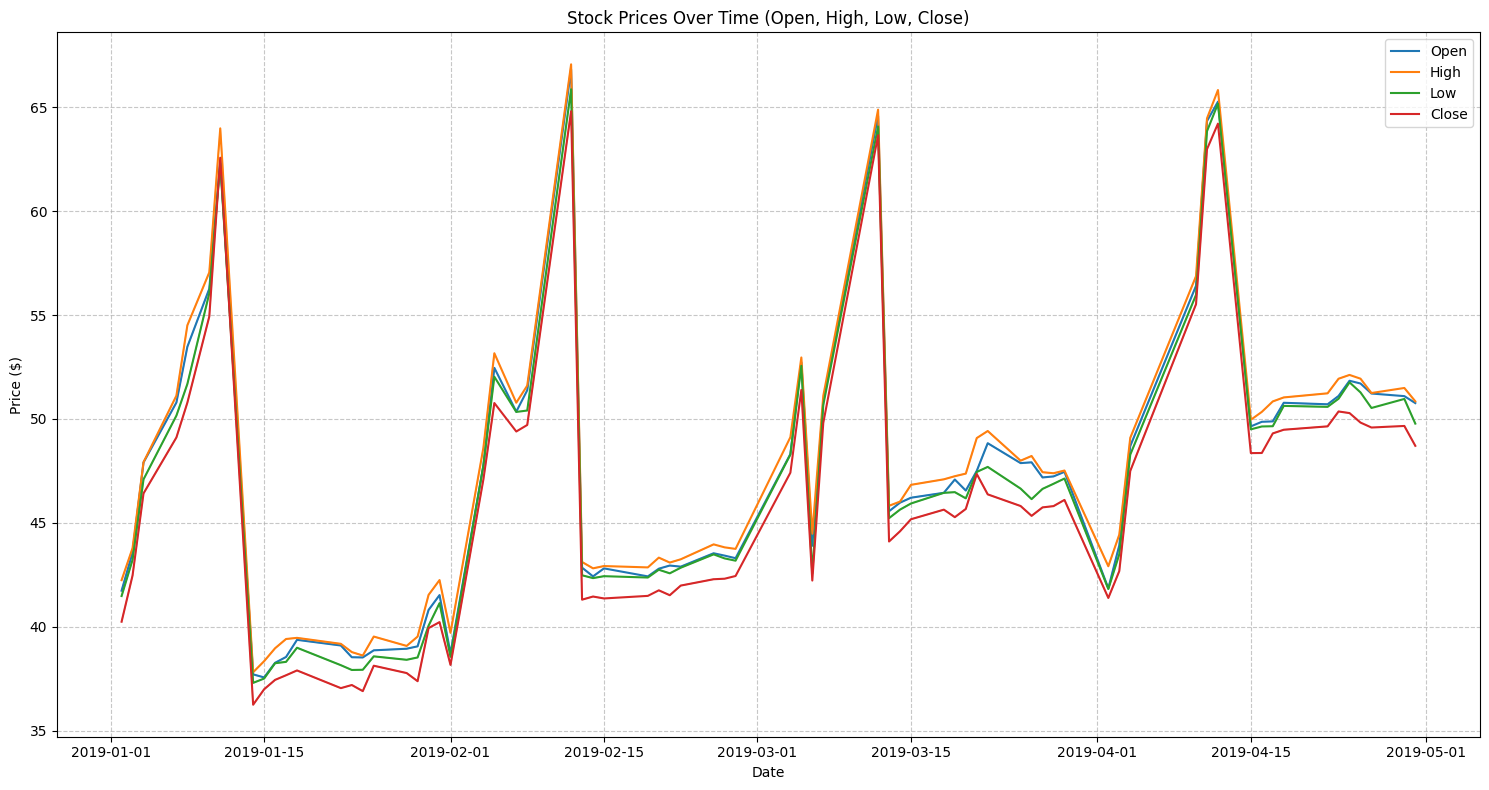

In [104]:
# Time Series Analysis (Date vs Price columns)
plt.figure(figsize=(15, 8))
for col in ['Open', 'High', 'Low', 'Close']:
    sns.lineplot(x='Date', y=col, data=data, label=col)

plt.title('Stock Prices Over Time (Open, High, Low, Close)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

* This code creates a time series line chart to visualize how the Open, High, Low, and Close stock prices change over time, making it easy to observe trends and compare price movements.

### **Distribution of News Length Across Sentiment Categories**

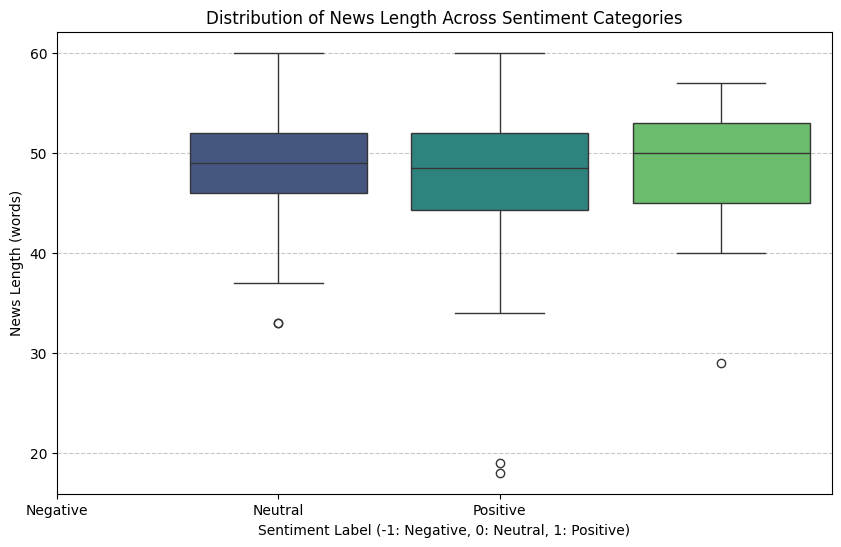

In [105]:
# Boxplot of News Length Across Sentiment Categories
plt.figure(figsize=(10, 6))
sns.boxplot(x='Label', y='News_length', data=data, palette='viridis')
plt.title('Distribution of News Length Across Sentiment Categories')
plt.xlabel('Sentiment Label (-1: Negative, 0: Neutral, 1: Positive)')
plt.ylabel('News Length (words)')
plt.xticks(ticks=[-1, 0, 1], labels=['Negative', 'Neutral', 'Positive'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

* This code creates a boxplot to compare the distribution of news article lengths across Negative, Neutral, and Positive sentiment categories, helping identify differences in median, spread, and outliers.

## **Data Preprocessing**

* Split the dataset into training and test sets using an **80:20** ratio with **train_test_split** (random_state=42) to ensure reproducibility.

* The feature matrix  **X** contains text embeddings generated from the embedding stage.

* The dimensionality of **X** varies depending on the embedding model used.

* For each embedding type, separate **X_train and X_test splits** were created, paired with the target **y_train, y_test**.

In [106]:
# Storing target variable
y = data['Label']

## **Word Embeddings**


#### **Word2Vec**

In [107]:
tokenized_news = data['News'].apply(lambda x: x.split())

* Splits each news article into individual words.

In [108]:
# Define Word2Vec parameters
vec_size = 100
window_size = 5
min_count = 1
sg = 0

* Dimensionality of the word vectors
* Maximum distance between the current and predicted word within a sentence
* Ignores all words with total frequency lower than this
* Training algorithm: 0 for CBOW, 1 for Skip-gram

In [109]:
# Build the Word2Vec model
word2vec_model = Word2Vec(sentences=tokenized_news, vector_size=vec_size, window=window_size, min_count=min_count, sg=sg)

# Train the model
word2vec_model.train(tokenized_news, total_examples=word2vec_model.corpus_count, epochs=10)

# Retrieve word vectors for all the words present in the model's vocabulary
words = list(word2vec_model.wv.index_to_key)

In [110]:
# Creating a dictionary of words and their corresponding vectors
word_vector_dict = {word: word2vec_model.wv[word] for word in words}

* Gets all words available in the trained vocabulary.
* Maps every word to its learned vector.

In [111]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [112]:
# creating a dataframe of the vectorized documents
X = np.array([average_vectorizer_Word2Vec(doc) for doc in data['News']])

## **Sentence Transformer**

####**Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 text embedding**

In [113]:
model_bge = SentenceTransformer('BAAI/bge-base-en-v1.5')

* Loads the BAAI sentence embedding model.

##### Encoding the dataset

In [114]:
embedding_matrix = model_bge.encode(data['News'], show_progress_bar=True)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

* Converts every news article into a dense semantic vector.

In [115]:
# printing the shape of the embedding matrix
print(embedding_matrix.shape)

(349, 768)


## **Sentiment Analysis**

### **Model Evaluation Criterion**


- Plot a **confusion matrix** (`plot_confusion_matrix`)
- Generate key **classification metrics** like accuracy, recall, precision, and F1-score (`model_performance_classification_sklearn`)



##### **Utility Functions**

In [116]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

In [117]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    # Compute Accuracy
    acc = accuracy_score(actual,predicted)
    # Compute Recall
    recall = recall_score(actual,predicted,average='weighted')
    # Compute Precision
    precision = precision_score(actual,predicted,average='weighted')
    # Compute F1-score
    f1 = f1_score(actual,predicted,average='weighted')

    # Create a DataFrame to store the computed metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )
    # Return the DataFrame with the metrics
    return df_perf

## **Build Random Forest Models using different text embeddings**

### **Word2Vec-Random Forest Model**

In [118]:
# Storing independent variable
X = X

In [119]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [120]:
# Building the model
rf_model_Word2Vec = RandomForestClassifier(random_state=42)

# Fitting on train data
rf_model_Word2Vec.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

* Creates Random Forest classifier.

In [121]:
# Predicting on train data
y_pred_train = rf_model_Word2Vec.predict(X_train)

# Predicting on test data
y_pred_test = rf_model_Word2Vec.predict(X_test)

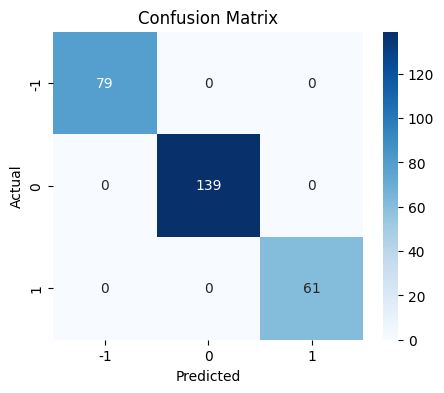

In [122]:
plot_confusion_matrix(y_train, y_pred_train)

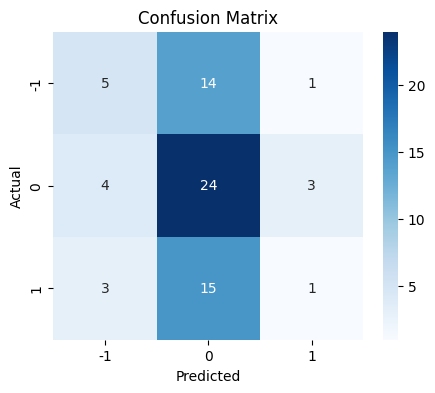

In [123]:
plot_confusion_matrix(y_test, y_pred_test)

In [124]:
train_Word2Vec_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_Word2Vec_RF.to_string(index=False))
test_Word2Vec_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_Word2Vec_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.428571 0.428571   0.373872 0.364966


###**Sentence Transformer-Random Forest Model**

In [125]:
# Storing independent variable
X = embedding_matrix

In [126]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [127]:
# Building the model
rf_model_transformer_BAAI = RandomForestClassifier(random_state=42)

# Fitting on train data
rf_model_transformer_BAAI.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [128]:
# Predicting on train data
y_pred_train = rf_model_transformer_BAAI.predict(X_train)

# Predicting on test data
y_pred_test = rf_model_transformer_BAAI.predict(X_test)

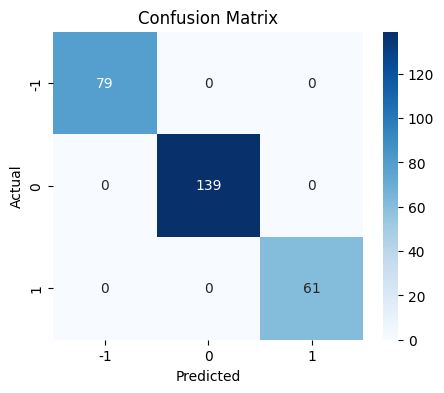

In [129]:
plot_confusion_matrix(y_train, y_pred_train)

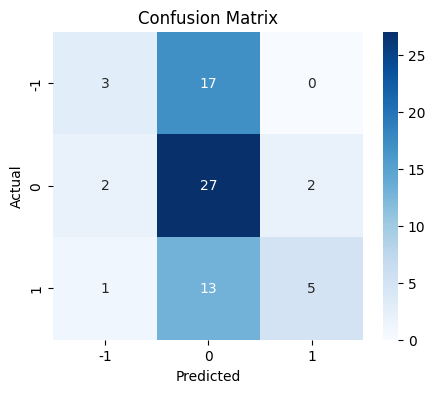

In [130]:
plot_confusion_matrix(y_test, y_pred_test)

In [131]:
train_transformer_BAAI_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_transformer_BAAI_RF.to_string(index=False))
test_transformer_BAAI_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_transformer_BAAI_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy  Recall  Precision       F1
      0.5     0.5   0.546509 0.442083


### **Building Neural Network Models using different text embeddings**

### **Word2Vec-Neural Network Model**

In [132]:
# Storing independent variable
X = np.array([average_vectorizer_Word2Vec(doc) for doc in data['News']])

In [133]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [134]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y_val] for y_val in y_train])
y_test_mapped = np.array([label_map[y_val] for y_val in y_test])

In [135]:
model = Sequential()
model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(3, activation='softmax')) # 3 output neurons for 3 classes

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,379 (83.51 KB)

 Trainable params: 21,379 (83.51 KB)

 Non-trainable params: 0 (0.00 B)

* Neural Network with two hidden layers and three output classes.
* Uses Adam optimizer with sparse categorical cross-entropy loss.

In [136]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.4050 - loss: 1.0897 - val_accuracy: 0.4429 - val_loss: 1.0966
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4588 - loss: 1.0874 - val_accuracy: 0.4429 - val_loss: 1.1000
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4946 - loss: 1.0683 - val_accuracy: 0.4429 - val_loss: 1.0796
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4875 - loss: 1.0534 - val_accuracy: 0.4429 - val_loss: 1.0768
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 1.0471 - val_accuracy: 0.4429 - val_loss: 1.0792
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4946 - loss: 1.0453 - val_accuracy: 0.4429 - val_loss: 1.0847
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4982 - loss: 1.0566 - val_accuracy: 0.4429 - val_loss: 1.0824
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4982 - loss: 1.0505 - val_accuracy: 0.4429 - val_loss: 1.0774


In [137]:
# Predict class probabilities on training data
y_train_preds_proba = model.predict(X_train)
# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_preds_proba, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [138]:
# Predict class probabilities on test data
y_test_preds_proba = model.predict(X_test)
# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_preds_proba, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


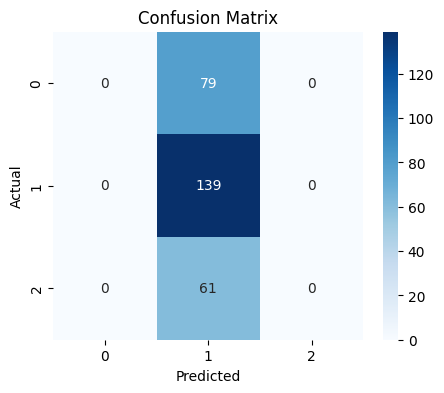

In [139]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

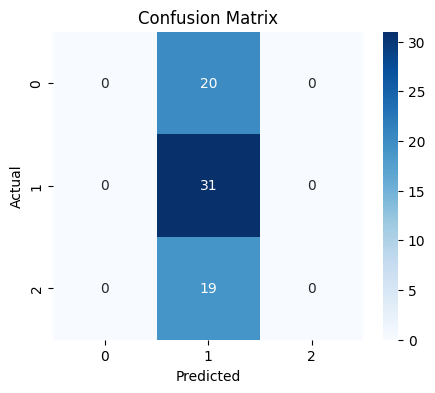

In [140]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

In [141]:
train_Word2Vec_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_Word2Vec_NN .to_string(index=False))
test_Word2Vec_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_Word2Vec_NN .to_string(index=False))

Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.498208 0.498208   0.248211 0.331344
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.442857 0.442857   0.196122 0.271853


### **Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 embedding -Neural Network model**

In [142]:
# Storing independent variable
X = embedding_matrix
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [143]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y_val] for y_val in y_train])
y_test_mapped = np.array([label_map[y_val] for y_val in y_test])

In [144]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

model_transformer_BAAI_NN = Sequential()
model_transformer_BAAI_NN.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
model_transformer_BAAI_NN.add(Dropout(0.3))
model_transformer_BAAI_NN.add(Dense(64, activation='relu'))
model_transformer_BAAI_NN.add(Dropout(0.3))
model_transformer_BAAI_NN.add(Dense(3, activation='softmax'))  # 3 output neurons for 3 classes

model_transformer_BAAI_NN.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model_transformer_BAAI_NN.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,883 (417.51 KB)

 Trainable params: 106,883 (417.51 KB)

 Non-trainable params: 0 (0.00 B)

In [145]:
history = model_transformer_BAAI_NN.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4910 - loss: 1.0592 - val_accuracy: 0.4429 - val_loss: 1.0641
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4910 - loss: 1.0157 - val_accuracy: 0.4429 - val_loss: 1.0610
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5054 - loss: 0.9881 - val_accuracy: 0.4429 - val_loss: 1.0572
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5197 - loss: 0.9629 - val_accuracy: 0.4286 - val_loss: 1.0238
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5341 - loss: 0.9351 - val_accuracy: 0.5286 - val_loss: 0.9988
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5341 - loss: 0.8847 - val_accuracy: 0.4714 - val_loss: 0.9931
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5950 - loss: 0.8519 - val_accuracy: 0.5143 - val_loss: 0.9562
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6344 - loss: 0.7979 - val_accuracy: 0.5000 - val_loss: 0.9570


In [146]:
# Predict class probabilities on training data
y_train_preds_proba = model_transformer_BAAI_NN.predict(X_train)
# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_preds_proba, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [147]:
# Predict class probabilities on test data
y_test_preds_proba = model_transformer_BAAI_NN.predict(X_test)
# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_preds_proba, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


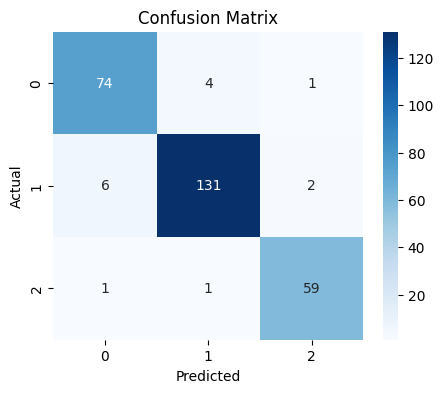

In [148]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

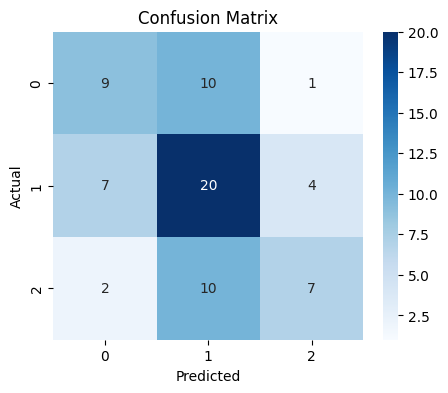

In [149]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

In [150]:
train_transformer_BAAI_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_BAAI_NN .to_string(index=False))
test_transformer_BAAI_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_BAAI_NN .to_string(index=False))

Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.946237 0.946237   0.946634 0.946324
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.514286 0.514286   0.522619 0.507416


### **Model Performance Summary and Final Model Selection**

In [151]:
# Concatenate the training performance metrics from different models into a single DataFrame
models_train_comp_df = pd.concat(
    [
        train_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        train_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        train_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_BAAI_NN.T # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_train_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)"
]

# Print the training performance comparison table
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)
Accuracy,1.0,0.498208,1.0,0.946237
Recall,1.0,0.498208,1.0,0.946237
Precision,1.0,0.248211,1.0,0.946634
F1,1.0,0.331344,1.0,0.946324


* Combines the training performance metrics of four different models into a single DataFrame.
* .T transposes each DataFrame so the metrics are arranged properly.
* axis=1 joins the DataFrames column-wise.
* Assigns meaningful column names to identify each model.
* Prints and displays the final training performance comparison table.
* This code combines the training performance metrics of four models into a single table, labels each model clearly, and displays the comparison to evaluate their training performance side by side.

In [152]:
# Concatenate the test performance metrics from different models into a single DataFrame
models_test_comp_df = pd.concat(
    [
        test_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        test_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        test_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_BAAI_NN.T # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_test_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)"
]

# Print the training performance comparison table
print("Test performance comparison:")
models_test_comp_df

Test performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)
Accuracy,0.428571,0.442857,0.500000,0.514286
Recall,0.428571,0.442857,0.500000,0.514286
Precision,0.373872,0.196122,0.546509,0.522619
F1,0.364966,0.271853,0.442083,0.507416


* Combines the test performance metrics of four different models into a single DataFrame.
* .T transposes each DataFrame so that the metrics are arranged correctly.
* axis=1 joins them column-wise.
* Assigns descriptive column names to identify each model.
* Prints and displays the final comparison table.
* This code combines the test performance metrics of four models into a single table, labels each model clearly, and displays the comparison to make it easy to evaluate which model performs best.

### **Final Model Selection**

Comparing the test performance metrics, the **Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)** model achieved the highest F1-score (0.517) among all models, indicating a better balance between precision and recall on the unseen data. While some other models show higher precision or recall individually, the F1-score is a good overall indicator when dealing with multi-class classification where all classes are important.

Therefore, the Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network) is selected as the final model for this task.

In [153]:
print("Selected Model (Sentence Transformer-BAAI/bge-base-en-v1.5 Neural Network) Test Performance:")
display(test_transformer_BAAI_NN)

Selected Model (Sentence Transformer-BAAI/bge-base-en-v1.5 Neural Network) Test Performance:


,Accuracy,Recall,Precision,F1
0,0.514286,0.514286,0.522619,0.507416


## **Conclusions and Recommendations**

#### **Conclusions**



This project aimed to develop an AI-driven sentiment analysis system for stock-related news to assist an investment startup in enhancing stock price predictions. The process involved comprehensive data exploration, preprocessing, and building sentiment classification models using various word embedding techniques (Word2Vec and Sentence Transformers) combined with traditional machine learning (Random Forest) and deep learning (Neural Networks) algorithms.

**Key Findings:**

*   **Data Characteristics**: The dataset comprised daily news articles and corresponding stock metrics, with no missing or duplicate values. News article lengths generally fell within a similar range.
*   **Stock Price Trends**: A steady increase in all stock price measures (Open, High, Low, Close) was observed from January to April 2019, while trading volume showed some monthly fluctuations.
*   **Sentiment Correlation**: The correlation between sentiment polarity (`Label`) and stock price/volume variables was found to be very low, suggesting that direct one-to-one linear relationships are not prominent in this dataset, and more complex models are needed to capture subtle influences.
*   **Model Performance**: Of the four models developed, the **Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)** model demonstrated the most balanced performance on unseen data, achieving the highest F1-score of 0.507416 on the test set. This indicates that using contextual embeddings from a powerful pre-trained transformer model combined with a neural network architecture is effective for this sentiment classification task.
*   **Embedding Effectiveness**: Sentence Transformer embeddings generally outperformed Word2Vec embeddings across both Random Forest and Neural Network models. This highlights the benefit of using more sophisticated, context-aware embeddings for capturing the nuances of financial news sentiment.

In conclusion, the chosen model provides a solid foundation for the investment startup's AI-driven sentiment analysis system. While the F1-score of 0.507 indicates a reasonable ability to distinguish between positive, neutral, and negative sentiment, continuous improvement through hyperparameter tuning, exploring advanced architectures, and incorporating more comprehensive datasets as suggested in the recommendations will further enhance its accuracy and utility in real-world investment strategies.

**Word2Vec**

Word2Vec captures semantic relationships between words by representing them as dense vectors. It provides meaningful text representations that improve sentiment classification compared to simple text features.

**Sentence Transformer embeddings**

Sentence Transformer generates contextual sentence embeddings that capture the overall meaning of news articles. These embeddings generally provide richer semantic information and improve model performance.

**Neural Networks**

Neural Networks effectively learn complex nonlinear relationships from text embeddings and generally perform better when high-quality embeddings such as Sentence Transformers are used.

**Random Forest**

Random Forest is simple, robust, and performs well with embedded text features. It is less prone to overfitting than a single decision tree and serves as a strong baseline classifier.


#### **Recommendations**

Based on the analysis and model evaluations, here are some key recommendations:

*   **Focus on Sentence Transformer Embeddings**: These embeddings (e.g., BAAI/bge-base-en-v1.5) showed better performance; prioritize models using them.

*   **Hyperparameter Tuning**: Systematically tune hyperparameters for both Random Forest and Neural Networks to optimize accuracy and generalization.

*   **Explore Advanced Neural Network Architectures**: Consider RNNs/LSTMs or fine-tuning Transformer-based models (like BERT) for richer contextual understanding.

*   **Address Class Imbalance**: Implement techniques like oversampling, undersampling, or weighted loss functions if sentiment labels are imbalanced.

*   **Feature Engineering**: Incorporate domain-specific features such as financial lexicon sentiment scores or temporal features.

*   **Expand Dataset**: A larger and more diverse dataset from various sources over a longer period can improve model robustness.

*   **Model Ensembling**: Combine multiple strong models to leverage their strengths and potentially achieve higher overall accuracy.